In [4]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

filename = "TS/trace_maths_Rp_NEWAVO_IL6251.sgy"

with segyio.open(filename, "r") as f:
    f.mmap()

    data = segyio.tools.cube(f)  # (iline, xline, time)
    ilines = f.ilines
    xlines = f.xlines
    time   = f.samples

print("Cube shape:", data.shape)


Cube shape: (1, 351, 1001)


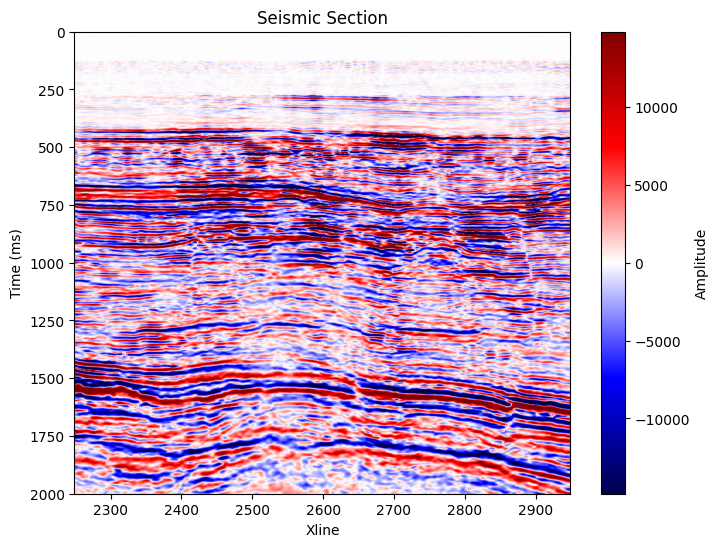

In [5]:
plt.figure(figsize=(8,6))
plt.imshow(
    data.T,
    aspect='auto',
    cmap='seismic',
    vmin=-np.percentile(data, 98),
    vmax= np.percentile(data, 98),
    extent=[xlines[0], xlines[-1], time[-1], time[0]]
)
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.title("Seismic Section")
plt.colorbar(label="Amplitude")
plt.show()

In [6]:
xlines

array([2249, 2251, 2253, 2255, 2257, 2259, 2261, 2263, 2265, 2267, 2269,
       2271, 2273, 2275, 2277, 2279, 2281, 2283, 2285, 2287, 2289, 2291,
       2293, 2295, 2297, 2299, 2301, 2303, 2305, 2307, 2309, 2311, 2313,
       2315, 2317, 2319, 2321, 2323, 2325, 2327, 2329, 2331, 2333, 2335,
       2337, 2339, 2341, 2343, 2345, 2347, 2349, 2351, 2353, 2355, 2357,
       2359, 2361, 2363, 2365, 2367, 2369, 2371, 2373, 2375, 2377, 2379,
       2381, 2383, 2385, 2387, 2389, 2391, 2393, 2395, 2397, 2399, 2401,
       2403, 2405, 2407, 2409, 2411, 2413, 2415, 2417, 2419, 2421, 2423,
       2425, 2427, 2429, 2431, 2433, 2435, 2437, 2439, 2441, 2443, 2445,
       2447, 2449, 2451, 2453, 2455, 2457, 2459, 2461, 2463, 2465, 2467,
       2469, 2471, 2473, 2475, 2477, 2479, 2481, 2483, 2485, 2487, 2489,
       2491, 2493, 2495, 2497, 2499, 2501, 2503, 2505, 2507, 2509, 2511,
       2513, 2515, 2517, 2519, 2521, 2523, 2525, 2527, 2529, 2531, 2533,
       2535, 2537, 2539, 2541, 2543, 2545, 2547, 25

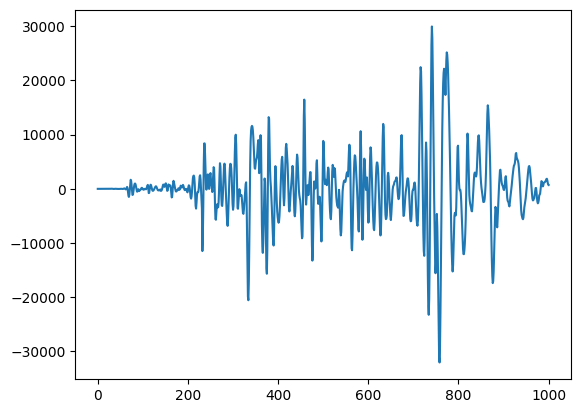

In [7]:
plt.plot(data[0,1,:])

In [8]:
import numpy as np

def s_transform_correct(trace, dt, fmin, fmax, df, gamma=1.0):
    trace = np.asarray(trace)
    nt = trace.size
    t = np.arange(nt) * dt

    freqs = np.arange(fmin, fmax + df, df)
    S = np.zeros((len(freqs), nt), dtype=complex)

    for i, f in enumerate(freqs):
        if f == 0:
            continue

        sigma = gamma / abs(f)

        for tau in range(nt):
            window = np.exp(
                -((t - t[tau])**2) / (2 * sigma**2)
            )
            S[i, tau] = np.sum(
                trace * window * np.exp(-1j * 2 * np.pi * f * t)
            )

    return np.abs(S), freqs, t

In [9]:
def wiggle_trace(ax, trace, t, scale=1.0, color='k'):
    trace = trace / np.max(np.abs(trace)) * scale
    ax.plot(trace, t, color=color, linewidth=1)
    ax.fill_betweenx(
        t, 0, trace,
        where=(trace > 0),
        color=color,
        alpha=0.6
    )


In [ ]:
dt = 0.002
signal = data[0,1,:]

S, f, t = s_transform_correct(
    signal,
    dt=dt,
    fmin=1,
    fmax=60,
    df=5,
    gamma=0.5
)

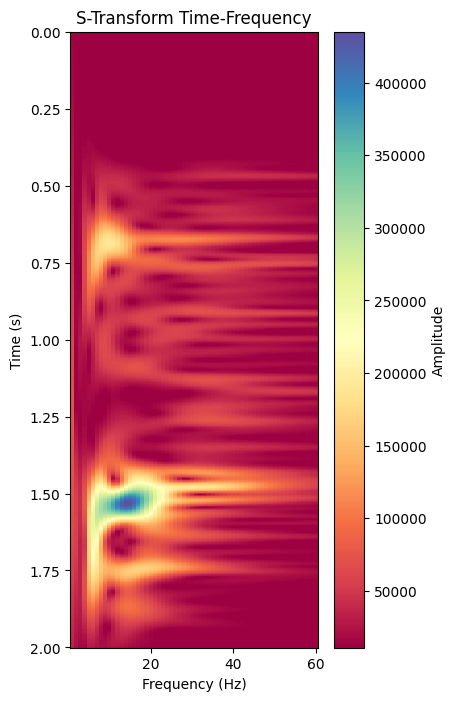

In [11]:
plt.figure(figsize=(4,8))
plt.pcolormesh(
    f,
    t,
    S.T,
    shading='auto',
    cmap='Spectral', 
    vmin= np.percentile(S, 30),
    vmax= np.percentile(S, 100)
)
plt.ylabel("Time (s)")
plt.gca().invert_yaxis()
plt.xlabel("Frequency (Hz)")
plt.title("S-Transform Time-Frequency")
plt.colorbar(label="Amplitude")
plt.show()

In [50]:
S.shape

(60, 1001)

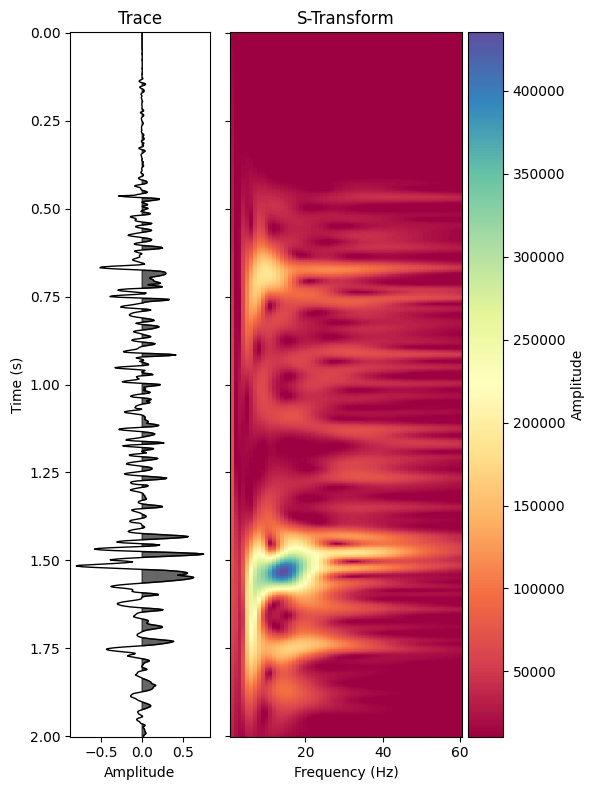

In [49]:
fig, (ax_wig, ax_tf) = plt.subplots(
    ncols=2,
    figsize=(6,8),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 2]}
)

# --- Wiggle plot (kiri) ---
wiggle_trace(
    ax_wig,
    trace=signal,    # ganti dengan trace seismik kamu
    t=t,
    scale=0.8
)
ax_wig.set_xlabel("Amplitude")
ax_wig.set_ylabel("Time (s)")
ax_wig.invert_yaxis()
ax_wig.set_title("Trace")

# --- S-Transform (kanan) ---
im = ax_tf.pcolormesh(
    f,
    t,
    S.T,
    shading='auto',
    cmap='Spectral',
    vmin=np.percentile(S, 30),
    vmax=np.percentile(S, 100)
)
ax_tf.set_xlabel("Frequency (Hz)")
ax_tf.set_title("S-Transform")

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax_tf, pad=0.02)
cbar.set_label("Amplitude")

plt.tight_layout()
plt.show()
